In [4]:
from google.colab import drive
drive.mount('/content/drive')
print('Google Drive mounted ✅')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted ✅


In [5]:
!pip install pycocotools segmentation-models-pytorch torch torchvision albumentations tqdm


In [6]:
# Download COCO validation set (images)
!wget http://images.cocodataset.org/zips/val2017.zip

# Download COCO annotations
!wget http://images.cocodataset.org/annotations/annotations_trainval2017.zip

# Extract into your Drive
!unzip -q val2017.zip -d /content/drive/MyDrive/VISION_AI/
!unzip -q annotations_trainval2017.zip -d /content/drive/MyDrive/VISION_AI/

print("✅ COCO val2017 and annotations downloaded and extracted")


--2025-09-23 17:44:11--  http://images.cocodataset.org/zips/val2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 16.182.99.193, 16.182.37.217, 52.217.45.220, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|16.182.99.193|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 815585330 (778M) [application/zip]
Saving to: ‘val2017.zip.1’

val2017.zip.1       100%[===================>] 777.80M  58.7MB/s    in 14s     

2025-09-23 17:44:25 (54.1 MB/s) - ‘val2017.zip.1’ saved [815585330/815585330]

--2025-09-23 17:44:25--  http://images.cocodataset.org/annotations/annotations_trainval2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 16.182.99.65, 52.217.228.145, 16.182.67.249, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|16.182.99.65|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 252907541 (241M) [application/zip]
Saving to: ‘annotations_trainval2017.zip.2’

annotations_

In [7]:
import os
from tqdm import tqdm
from PIL import Image, ImageDraw
from pycocotools.coco import COCO

# Paths
coco_annotation_path = "/content/drive/MyDrive/VISION_AI/annotations/instances_val2017.json"
images_dir = "/content/drive/MyDrive/VISION_AI/val2017"
masks_output_dir = "/content/drive/MyDrive/VISION_AI/Binary_Mask"

os.makedirs(masks_output_dir, exist_ok=True)

# Load COCO annotations
coco = COCO(coco_annotation_path)
img_ids = coco.getImgIds()

for img_id in tqdm(img_ids):
    img_info = coco.loadImgs(img_id)[0]
    file_name = img_info['file_name']
    width, height = img_info['width'], img_info['height']

    # Create blank mask
    mask = Image.new('L', (width, height), 0)
    mask_draw = ImageDraw.Draw(mask)

    ann_ids = coco.getAnnIds(imgIds=img_id, iscrowd=None)
    anns = coco.loadAnns(ann_ids)

    for ann in anns:
        seg = ann.get('segmentation', None)
        if seg and isinstance(seg, list):
            for polygon in seg:
                mask_draw.polygon(polygon, outline=1, fill=1)
        else:
            m = coco.annToMask(ann)
            m_img = Image.fromarray(m * 255)
            mask = Image.composite(m_img, mask, m_img)

    # Save mask
    mask_path = os.path.join(masks_output_dir, os.path.splitext(file_name)[0] + ".png")
    mask.save(mask_path)

print("✅ Binary masks generated in /Binary_Mask")


loading annotations into memory...
Done (t=0.60s)
creating index...
index created!


100%|██████████| 5000/5000 [01:03<00:00, 78.69it/s]

✅ Binary masks generated in /Binary_Mask


In [8]:
images_dir = "/content/drive/MyDrive/VISION_AI/val2017"
masks_dir = "/content/drive/MyDrive/VISION_AI/Binary_Mask"
annotations_dir = "/content/drive/MyDrive/VISION_AI/annotations"


In [9]:
import torch
import segmentation_models_pytorch as smp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Using device:", device)

# Define U-Net with ResNet34 backbone
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",  # pretrained encoder
    in_channels=3,
    classes=1,  # binary segmentation
)
model.to(device)

print("✅ VANISRI U-Net with ResNet34 initialized")


✅ Using device: cpu
✅ VANISRI U-Net with ResNet34 initialized


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [10]:
!wget http://images.cocodataset.org/zips/val2017.zip
!wget http://images.cocodataset.org/annotations/annotations_trainval2017.zip

!unzip -q val2017.zip -d /content/drive/MyDrive/VISION_AI/
!unzip -q annotations_trainval2017.zip -d /content/drive/MyDrive/VISION_AI/


--2025-09-23 17:46:35--  http://images.cocodataset.org/zips/val2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 3.5.28.142, 3.5.29.135, 3.5.29.45, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|3.5.28.142|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 815585330 (778M) [application/zip]
Saving to: ‘val2017.zip.2’

val2017.zip.2       100%[===================>] 777.80M  54.4MB/s    in 14s     

2025-09-23 17:46:49 (55.5 MB/s) - ‘val2017.zip.2’ saved [815585330/815585330]

--2025-09-23 17:46:49--  http://images.cocodataset.org/annotations/annotations_trainval2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 3.5.11.119, 3.5.25.213, 52.217.68.100, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|3.5.11.119|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 252907541 (241M) [application/zip]
Saving to: ‘annotations_trainval2017.zip.3’

annotations_trainva 100%[========

In [11]:
images_dir = "/content/drive/MyDrive/VISION_AI/images"   # if you renamed it
# or
images_dir = "/content/drive/MyDrive/VISION_AI/val2017"  # if it exists


In [12]:
!ls /content/drive/MyDrive/VISION_AI


annotations  Binary_Mask  val2017


In [13]:
# Remove any broken/partial downloads
!rm -f val2017.zip*

# Download fresh val2017 images
!wget http://images.cocodataset.org/zips/val2017.zip -O val2017.zip

# Unzip into VISION_AI folder
!unzip -q val2017.zip -d /content/drive/MyDrive/VISION_AI/


--2025-09-23 17:47:41--  http://images.cocodataset.org/zips/val2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 3.5.0.89, 3.5.27.135, 52.217.123.97, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|3.5.0.89|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 815585330 (778M) [application/zip]
Saving to: ‘val2017.zip’

val2017.zip         100%[===================>] 777.80M  62.0MB/s    in 13s     

2025-09-23 17:47:54 (59.4 MB/s) - ‘val2017.zip’ saved [815585330/815585330]

replace /content/drive/MyDrive/VISION_AI/val2017/000000212226.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [14]:
!ls /content/drive/MyDrive/VISION_AI


annotations  Binary_Mask  val2017


In [15]:
images_dir = "/content/drive/MyDrive/VISION_AI/val2017"
masks_dir = "/content/drive/MyDrive/VISION_AI/Binary_Mask"
annotations_dir = "/content/drive/MyDrive/VISION_AI/annotations"

print("✅ Dataset paths set:")
print("Images:", images_dir)
print("Masks:", masks_dir)
print("Annotations:", annotations_dir)


✅ Dataset paths set:
Images: /content/drive/MyDrive/VISION_AI/val2017
Masks: /content/drive/MyDrive/VISION_AI/Binary_Mask
Annotations: /content/drive/MyDrive/VISION_AI/annotations


In [16]:
# Step 4: Dataset Loader (with resize fix)
import os
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import torch
import torchvision.transforms as T

class CocoDataset(Dataset):
    def __init__(self, images_dir, masks_dir, transform=None, target_size=(128, 128)):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.image_files = sorted(os.listdir(images_dir))
        self.mask_files = sorted(os.listdir(masks_dir))
        self.transform = transform
        self.target_size = target_size

        self.resize_img = T.Resize(target_size)
        self.resize_mask = T.Resize(target_size)

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image = Image.open(os.path.join(self.images_dir, self.image_files[idx])).convert("RGB")
        mask = Image.open(os.path.join(self.masks_dir, self.mask_files[idx])).convert("L")

        # Resize
        image = self.resize_img(image)
        mask = self.resize_mask(mask)

        # Normalize
        image = np.array(image) / 255.0
        mask = np.array(mask) / 255.0
        mask = np.expand_dims(mask, axis=0)

        image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1)
        mask = torch.tensor(mask, dtype=torch.float32)

        return image, mask



In [17]:
import torch.nn as nn
import torch.nn.functional as F

class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()
        self.enc1 = nn.Sequential(nn.Conv2d(3, 64, 3, padding=1), nn.ReLU(), nn.Conv2d(64, 64, 3, padding=1), nn.ReLU())
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = nn.Sequential(nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.Conv2d(128, 128, 3, padding=1), nn.ReLU())
        self.pool2 = nn.MaxPool2d(2)

        self.bottleneck = nn.Sequential(nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(), nn.Conv2d(256, 256, 3, padding=1), nn.ReLU())

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = nn.Sequential(nn.Conv2d(256, 128, 3, padding=1), nn.ReLU(), nn.Conv2d(128, 128, 3, padding=1), nn.ReLU())
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = nn.Sequential(nn.Conv2d(128, 64, 3, padding=1), nn.ReLU(), nn.Conv2d(64, 64, 3, padding=1), nn.ReLU())

        self.final = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        b = self.bottleneck(self.pool2(e2))
        d2 = self.dec2(torch.cat([self.up2(b), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return torch.sigmoid(self.final(d1))


In [18]:
# Step 5: Define Hyperparameters
batch_size = 4
learning_rate = 1e-4
num_epochs = 10

# Dataset & DataLoader
train_dataset = CocoDataset(images_dir, masks_dir)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

print(f"✅ Dataset ready: {len(train_dataset)} samples")


✅ Dataset ready: 5000 samples


In [19]:
# ✅ Use only 100 images for quick testing
subset_size = 100
train_dataset = CocoDataset(images_dir, masks_dir, target_size=(128, 128))
train_dataset = torch.utils.data.Subset(train_dataset, range(subset_size))

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.BCELoss()

num_epochs = 3   # keep small for testing

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for batch_idx, (images, masks) in enumerate(train_loader):
        images, masks = images.to(device), masks.to(device)

        preds = model(images)
        loss = criterion(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        # Print every 5 batches
        if batch_idx % 5 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Batch [{batch_idx}/{len(train_loader)}], Loss: {loss.item():.4f}")

    print(f"✅ Epoch [{epoch+1}/{num_epochs}] Avg Loss: {epoch_loss/len(train_loader):.4f}")



Epoch [1/3], Batch [0/25], Loss: 0.7451
Epoch [1/3], Batch [5/25], Loss: 0.7239
Epoch [1/3], Batch [10/25], Loss: 0.7164
Epoch [1/3], Batch [15/25], Loss: 0.6865
Epoch [1/3], Batch [20/25], Loss: 0.5966
✅ Epoch [1/3] Avg Loss: 0.6688
Epoch [2/3], Batch [0/25], Loss: 0.3782
Epoch [2/3], Batch [5/25], Loss: 0.0207
Epoch [2/3], Batch [10/25], Loss: 0.0505
Epoch [2/3], Batch [15/25], Loss: 0.0417
Epoch [2/3], Batch [20/25], Loss: 0.0667
✅ Epoch [2/3] Avg Loss: 0.4392
Epoch [3/3], Batch [0/25], Loss: 0.0083
Epoch [3/3], Batch [5/25], Loss: 0.0249
Epoch [3/3], Batch [10/25], Loss: 0.1560
Epoch [3/3], Batch [15/25], Loss: 0.0518
Epoch [3/3], Batch [20/25], Loss: 0.0263
✅ Epoch [3/3] Avg Loss: 0.1214


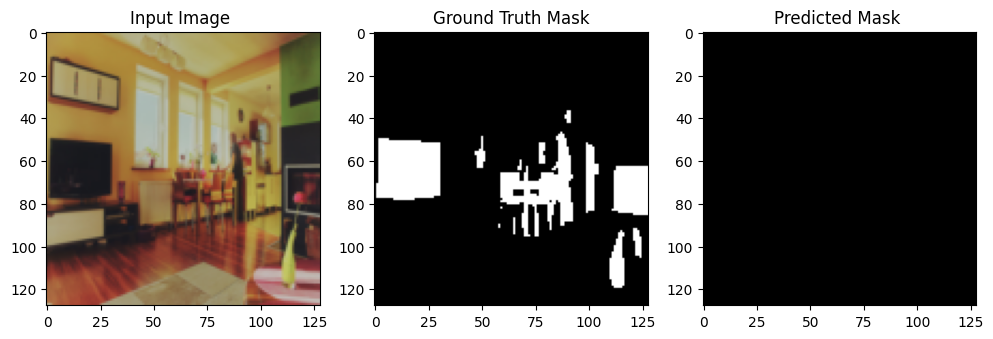

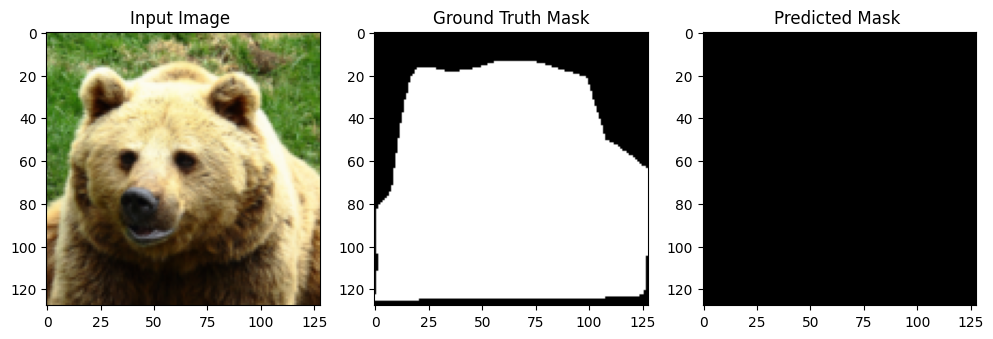

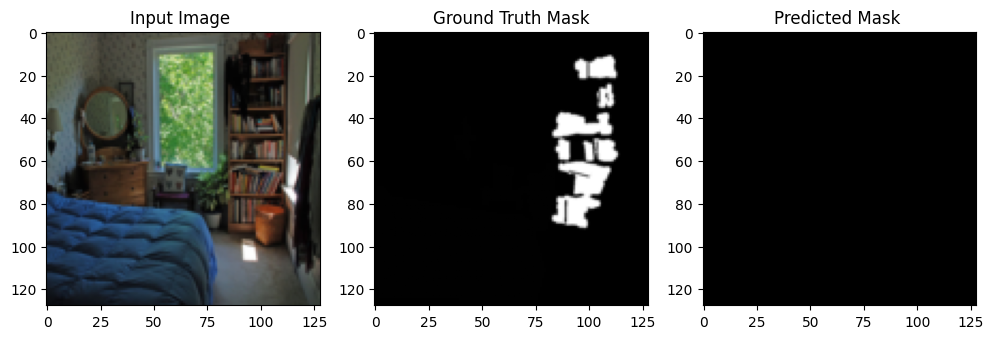

In [21]:
import matplotlib.pyplot as plt

# Put model in evaluation mode
model.eval()

# Pick a few samples
num_samples = 3
for i in range(num_samples):
    image, mask = train_dataset[i]
    image_input = image.unsqueeze(0).to(device)  # Add batch dim

    with torch.no_grad():
        pred = model(image_input)
        pred = (pred > 0.5).float().cpu().squeeze()  # Threshold at 0.5

    # Plot input, ground truth, prediction
    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    plt.imshow(image.permute(1,2,0).cpu())
    plt.title("Input Image ")

    plt.subplot(1,3,2)
    plt.imshow(mask.squeeze(), cmap="gray")
    plt.title("Ground Truth Mask")

    plt.subplot(1,3,3)
    plt.imshow(pred, cmap="gray")
    plt.title("Predicted Mask ")

    plt.show()


In [22]:
# Save the trained model
model_path = "/content/drive/MyDrive/VISION_AI/unet_vanisri.pth"
torch.save(model.state_dict(), model_path)
print(f"✅ Model saved at {model_path}")


✅ Model saved at /content/drive/MyDrive/VISION_AI/unet_vanisri.pth


In [23]:
# Recreate model and load weights
model = UNet().to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

print("✅ Model loaded and ready to use")


✅ Model loaded and ready to use
